# Image Prefill — Sandbox (v2, DB-backed)

Thin harness over [`sandbox/prefill_lib.py`](prefill_lib.py) — the app-ready library.
Reference data comes from the **Django ORM** (not CSVs), and all extractor/resolver
logic lives in the module so it lifts straight into the eventual `prefill/` package.

**Run order**
1. Seed the DB once: `python manage.py seed_states && python manage.py seed_geographic_units && python manage.py seed_license_types`
2. Put `ANTHROPIC_API_KEY` in the repo-root `.env`.
3. Run the cells top to bottom.

Edit `prefill_lib.py` and re-run — `autoreload` picks up changes without restarting the kernel.

In [1]:
%pip install anthropic python-dotenv pillow rapidfuzz pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Bootstrap: put repo root + sandbox on path, load the library (DB-backed)
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'manage.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
for p in (str(ROOT), str(ROOT / 'sandbox')):
    if p not in sys.path:
        sys.path.insert(0, p)

%load_ext autoreload
%autoreload 2
import prefill_lib as P

REF = P.ReferenceData()           # taxonomy snapshot from the Django ORM
CLIENT = P.get_client()           # None if ANTHROPIC_API_KEY is missing
print('PA counties:', len(REF.geo_by_state.get('PA', [])),
      '| license types:', sum(len(v) for v in REF.lt.values()),
      '| client:', 'ready' if CLIENT else 'NO API KEY')
print('Knobs -> MAX_IMAGE_EDGE:', P.MAX_IMAGE_EDGE, '| AUTO_CROP:', P.AUTO_CROP,
      '| ALLOW_INFERENCE:', P.ALLOW_INFERENCE, '| FUZZY_FLOOR:', P.FUZZY_FLOOR)

PA counties: 67 | license types: 534 | client: ready
Knobs -> MAX_IMAGE_EDGE: 1120 | AUTO_CROP: True | ALLOW_INFERENCE: True | FUZZY_FLOOR: 88


## Run extraction + resolution on the test images

[1/17] listing: test_listing_image_001.png


field,source_text,resolved,tier,conf,inferred
state,PENNA.,Pennsylvania,high,0.950000,
license_year,1940,1940,high,1.000000,
era_guess,1940s,1940s,medium,1.000000,
geographic_unit,Statewide,Statewide,high,0.900000,
is_statewide,True,True,high,0.900000,
residency,Resident,Resident,high,0.950000,
activity_scope,General Hunting,General Hunting,medium,0.700000,yes
duration,(inferred: antique tag),Annual,medium,0.700000,yes
material,Metal Button,Metal Button,high,0.850000,
shape,Rectangle,Rectangle,high,0.900000,

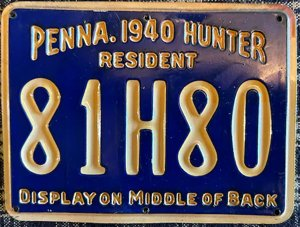

[2/17] listing: test_listing_image_002.png


field,source_text,resolved,tier,conf,inferred
state,PENNA.,Pennsylvania,high,1.000000,
license_year,1942,1942,high,1.000000,
era_guess,1940s,1940s,medium,1.000000,
geographic_unit,Statewide,Statewide,high,0.950000,
is_statewide,True,True,high,0.950000,
residency,Resident,Resident,high,0.950000,
activity_scope,General Hunting,General Hunting,high,0.950000,
duration,Annual,Annual,medium,0.750000,yes
material,Metal Tag,Metal Tag,high,0.900000,
shape,Rectangle,Rectangle,high,0.900000,

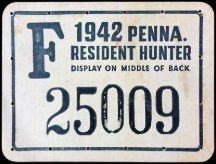

[3/17] listing: test_listing_image_003.png


field,source_text,resolved,tier,conf,inferred
state,PENNA.,Pennsylvania,high,0.980000,
license_year,1960,1960,high,0.980000,
era_guess,1960s,1960s,medium,0.990000,
geographic_unit,Franklin Co,Franklin,high,0.980000,
activity_scope,General Hunting,General Hunting,medium,0.850000,yes
duration,(inferred: antique tag),Annual,medium,0.700000,yes
addon_type,Antlerless Deer,Antlerless Deer Permit,medium,0.980000,
material,Metal Tag,Metal Tag,high,0.900000,
shape,Rectangle,Rectangle,high,0.920000,
colors,"gold, blue","Gold, Blue",medium,0.950000,

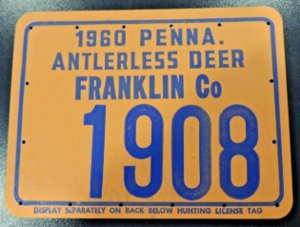

[4/17] listing: test_listing_image_004.png


field,source_text,resolved,tier,conf,inferred
state,PENNA.,Pennsylvania,high,0.950000,
license_year,1933,1933,high,0.950000,
era_guess,1930s,1930s,medium,0.950000,
geographic_unit,Co. 21,Cumberland,high,0.950000,
material,Metal Tag,Metal Tag,high,0.900000,
shape,Rectangle,Rectangle,high,0.900000,
colors,"black, white","Black, White",medium,0.950000,
serial_number,904,904,low,0.950000,

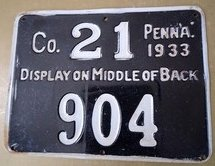

[5/17] listing: test_listing_image_005.png


field,source_text,resolved,tier,conf,inferred
state,PENNA.,Pennsylvania,high,0.980000,
license_year,1927,1927,high,0.980000,
geographic_unit,Co. #2,Allegheny,high,0.950000,
activity_scope,General Hunting,General Hunting,medium,0.700000,yes
duration,Annual,Annual,medium,0.700000,yes
material,Metal Tag,Metal Tag,high,0.900000,
shape,Tag (with hole),Tag (with hole),high,0.900000,
colors,"red, white, black","Red, White, Black",medium,0.950000,
serial_number,11561,11561,low,0.980000,

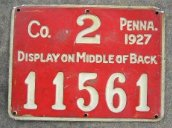

[6/17] listing: test_listing_image_006.png


field,source_text,resolved,tier,conf,inferred
state,PENNA.,Pennsylvania,high,0.950000,
license_year,1955,1955,high,0.950000,
geographic_unit,Statewide,Statewide,high,0.900000,
is_statewide,True,True,high,0.900000,
residency,Resident,Resident,high,0.950000,
activity_scope,General Hunting,General Hunting,high,0.900000,
duration,Annual,Annual,medium,0.650000,yes
material,Metal Tag,Metal Tag,high,0.900000,
shape,Rectangle,Rectangle,high,0.950000,
colors,"yellow, blue","Yellow, Blue",medium,0.950000,

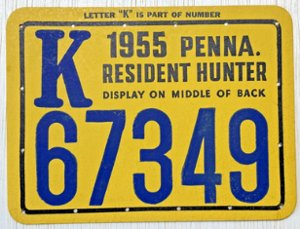

[7/17] listing: test_listing_image_007.png


field,source_text,resolved,tier,conf,inferred
state,OHIO,Ohio,high,1.000000,
license_year,1944,1944,high,1.000000,
era_guess,1940s,1940s,medium,1.000000,
geographic_unit,Statewide,Statewide,high,0.950000,
is_statewide,True,True,high,0.950000,
residency,Resident,Resident,high,1.000000,
activity_scope,General Hunting,General Hunting,high,0.950000,
duration,Annual,Annual,medium,0.650000,yes
material,Paper/Cardstock,Paper/Cardstock,high,0.850000,
shape,Rectangle,Rectangle,high,0.950000,

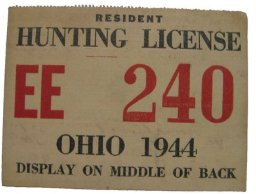

[8/17] listing: test_listing_image_008.png


field,source_text,resolved,tier,conf,inferred
state,PENNA.,Pennsylvania,high,0.950000,
license_year,1952,1952,high,0.950000,
geographic_unit,Northumberland Co,Northumberland,high,0.950000,
activity_scope,General Hunting,General Hunting,medium,0.900000,yes
duration,Annual,Annual,medium,0.650000,yes
addon_type,Antlerless Deer,Antlerless Deer Permit,medium,0.950000,
material,Paper/Cardstock,Paper/Cardstock,high,0.850000,
shape,Rectangle,Rectangle,high,0.900000,
colors,"tan, green, black","Brown/Tan, Forest Green, Black",medium,0.900000,
serial_number,191,191,low,0.950000,

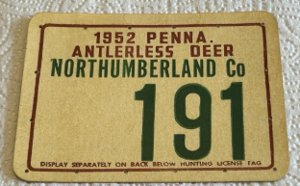

[9/17] listing: test_listing_image_009.png


field,source_text,resolved,tier,conf,inferred
state,MARYLAND,Maryland,high,0.990000,
license_year,1969,1969,high,0.990000,
geographic_unit,Statewide,Statewide,high,0.990000,
is_statewide,True,True,high,0.990000,
activity_scope,General Hunting,General Hunting,high,0.950000,
duration,Annual,Annual,medium,0.650000,yes
addon_type,"Turkey Tag, Deer Tag",Sika Deer Stamp,unmatched,0.990000,
material,Paper/Cardstock,Paper/Cardstock,high,0.850000,
shape,Strip,Strip,high,0.900000,
colors,"cream, blue","Cream/Ivory, Blue",medium,0.900000,

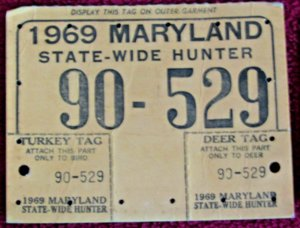

[10/17] collection: test_collection_image_001.png


field,source_text,resolved,tier,conf,inferred
state,PENNA.,Pennsylvania,high,0.980000,
license_year,1936,1936,high,0.980000,
era_guess,1930s,1930s,medium,0.950000,
geographic_unit,Co. 56,Somerset,high,0.950000,
activity_scope,General Hunting,General Hunting,medium,0.700000,yes
duration,Annual,Annual,medium,0.650000,yes
material,Metal Tag,Metal Tag,high,0.920000,
shape,Rectangle,Rectangle,high,0.900000,
colors,"green, gold, tan","Forest Green, Gold, Brown/Tan",medium,0.900000,
serial_number,21110,21110,low,0.980000,

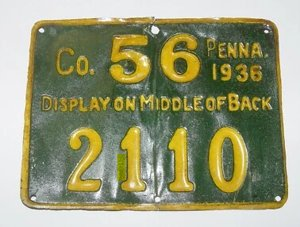

[11/17] collection: test_collection_image_002.png


field,source_text,resolved,tier,conf,inferred
state,PENNA.,Pennsylvania,high,1.000000,
license_year,1940,1940,high,1.000000,
geographic_unit,Statewide,Statewide,medium,0.750000,
is_statewide,True,True,medium,0.750000,yes
residency,Resident,Resident,high,1.000000,
activity_scope,General Hunting,General Hunting,high,0.950000,
duration,Annual,Annual,medium,0.700000,yes
material,Metal Tag,Metal Tag,high,0.950000,
shape,Rectangle,Rectangle,high,0.950000,
colors,"blue, gold, tan","Blue, Gold, Brown/Tan",medium,0.950000,

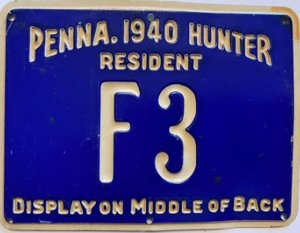

[12/17] collection: test_collection_image_003.png


field,source_text,resolved,tier,conf,inferred
state,PENNA.,Pennsylvania,high,0.950000,
license_year,1946,1946,high,0.950000,
era_guess,1940s,1940s,medium,0.950000,
geographic_unit,Statewide,Statewide,high,0.900000,
is_statewide,True,True,high,0.900000,
residency,Resident,Resident,high,0.950000,
holder_eligibility,General,General,medium,0.650000,yes
activity_scope,General Hunting,General Hunting,high,0.900000,
duration,Annual,Annual,medium,0.700000,yes
material,Metal Tag,Metal Tag,high,0.900000,

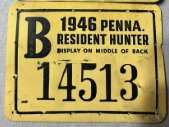

[13/17] collection: test_collection_image_004.png


field,source_text,resolved,tier,conf,inferred
state,PENNA.,Pennsylvania,high,0.950000,
license_year,1939,1939,high,0.950000,
era_guess,1930s,1930s,unmatched,0.000000,
geographic_unit,Statewide,Statewide,high,0.950000,
is_statewide,True,True,high,0.950000,
residency,Nonresident,Nonresident,high,0.950000,
activity_scope,General Hunting,General Hunting,high,0.950000,
duration,Annual,Annual,medium,0.650000,yes
material,Metal Tag,Metal Tag,high,0.900000,
shape,Rectangle,Rectangle,high,0.900000,

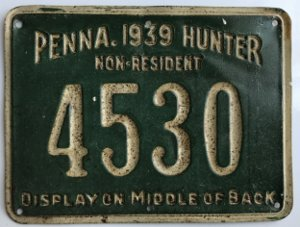

[14/17] collection: test_collection_image_005.png


field,source_text,resolved,tier,conf,inferred
license_year,1923,1923,high,0.980000,
era_guess,1920s,1920s,medium,0.950000,
geographic_unit,Co. 36,,unmatched,0.980000,
activity_scope,General Hunting,,unmatched,0.700000,
duration,Annual,,unmatched,0.650000,
material,Cardstock,Paper/Cardstock,medium,0.850000,
shape,Rectangle,Rectangle,high,0.900000,
colors,"blue, white, black","Blue, White, Black",medium,0.900000,
serial_number,1465,1465,low,0.980000,

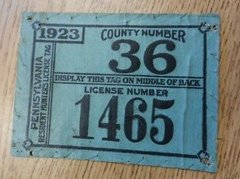

[15/17] collection: test_collection_image_006.png


field,source_text,resolved,tier,conf,inferred
state,PA.,Pennsylvania,high,0.950000,
license_year,1969,1969,high,0.950000,
era_guess,1960s,1960s,medium,0.950000,
geographic_unit,Statewide,Statewide,high,0.900000,
is_statewide,True,True,high,0.900000,
residency,Resident,Resident,high,0.950000,
holder_eligibility,General,General,high,0.950000,
activity_scope,General Hunting,General Hunting,high,0.900000,
duration,Annual,Annual,medium,0.700000,yes
addon_type,Turkey Tag,Special Spring Turkey Permit,medium,0.850000,

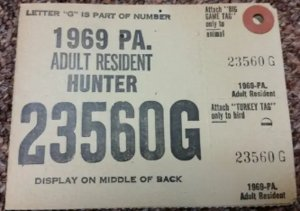

[16/17] collection: test_collection_image_007.png


field,source_text,resolved,tier,conf,inferred
state,MARYLAND,Maryland,high,0.980000,
geographic_unit,WASHINGTON COUNTY,Washington,high,0.950000,
residency,Resident,Resident,high,0.950000,
activity_scope,General Hunting,General Hunting,high,0.920000,
material,Paper/Cardstock,Paper/Cardstock,high,0.850000,
shape,Rectangle,Rectangle,high,0.900000,
colors,"green, black","Forest Green, Black",medium,0.900000,
serial_number,12563,12563,low,0.900000,

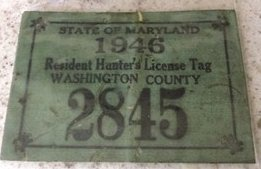

[17/17] collection: test_collection_image_008.png


field,source_text,resolved,tier,conf,inferred
state,PA.,Pennsylvania,high,0.950000,
license_year,1979,1979,high,0.950000,
era_guess,1970s,1970s,medium,0.950000,
geographic_unit,Statewide,Statewide,high,0.950000,
is_statewide,True,True,high,0.950000,
residency,Resident,Resident,high,0.950000,
holder_eligibility,General,General,high,0.950000,
activity_scope,General Hunting,General Hunting,high,0.950000,
duration,Annual,Annual,unmatched,0.000000,yes
addon_type,"Muzzle Loader, Antlerless Deer",Antlerless Deer Permit,unmatched,0.850000,

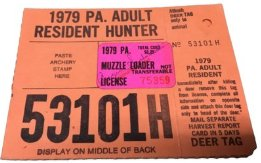

Done. 17 images, total $0.0664, avg 3.91 milli-$/image


In [2]:
import base64, glob
from io import BytesIO
from pathlib import Path

import pandas as pd
from IPython.display import HTML, display
from PIL import Image

FIELDS = ['state', 'license_year', 'era_guess', 'geographic_unit', 'is_statewide',
          'residency', 'holder_eligibility', 'activity_scope', 'duration',
          'addon_type', 'material', 'shape', 'colors', 'serial_number']
TIER_BG = {'high': '#d9f2d9', 'medium': '#fff3cd', 'low': '#ffe5cc', 'unmatched': '#f8d7da'}


def render(sf, path, res, ex):
    rows = []
    for k in FIELDS:
        d = res['fields'].get(k) or {}
        if not d.get('source_text') and not d.get('value'):
            continue
        rows.append({'field': k,
                     'source_text': str(d.get('source_text') or ''),
                     'resolved': str(d.get('name') or ''),
                     'tier': d.get('tier'),
                     'conf': round(d.get('conf', 0), 2),
                     'inferred': 'yes' if d.get('inferred') else ''})
    styled = (pd.DataFrame(rows).style.hide(axis='index')
              .map(lambda v: 'background-color:' + TIER_BG.get(v, '#fff'), subset=['tier']))
    with Image.open(path) as im:
        thumb = im.copy()
    thumb.thumbnail((300, 300))
    buf = BytesIO()
    thumb.convert('RGB').save(buf, 'JPEG', quality=85)
    b64 = base64.b64encode(buf.getvalue()).decode()
    meta = format(ex['cost_usd'] * 1000, '.2f') + ' milli-$ / ' + format(ex['latency_ms'], '.0f') + ' ms'
    img = '<img src="data:image/jpeg;base64,' + b64 + '" style="max-width:300px;border:1px solid #ccc;border-radius:6px">'
    head = '<b>' + sf + ': ' + path.name + '</b><br><span style="color:#666">' + meta + '</span><br>'
    display(HTML('<div style="display:flex;gap:20px;align-items:flex-start"><div>'
                 + head + img + '</div><div>' + styled.to_html() + '</div></div>'))
    display(HTML('<details><summary>raw transcription</summary><pre style="white-space:pre-wrap">'
                 + (res['raw_text'] or '(empty)') + '</pre></details>'))


def run_all(limit=None):
    dirs = [('listing', ROOT / 'media' / 'listings'), ('collection', ROOT / 'media' / 'collections')]
    imgs = [(sf, Path(p)) for sf, d in dirs for p in sorted(glob.glob(str(d / '*')))
            if Path(p).suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'}]
    if limit:
        imgs = imgs[:limit]
    out, cost = [], 0.0
    for i, (sf, path) in enumerate(imgs, 1):
        print('[' + str(i) + '/' + str(len(imgs)) + '] ' + sf + ': ' + path.name)
        ex = P.extract(str(path), CLIENT)
        if 'error' in ex:
            print('  error:', ex['error'])
            continue
        res = P.resolve(ex['raw'], REF)
        cost += ex['cost_usd']
        out.append({'sf': sf, 'name': path.name, 'ex': ex, 'res': res})
        render(sf, path, res, ex)
    avg = cost / max(len(out), 1) * 1000
    print('Done. ' + str(len(out)) + ' images, total $' + format(cost, '.4f')
          + ', avg ' + format(avg, '.2f') + ' milli-$/image')
    return out


results = run_all()

## Scratchpad

Single image, or iterate on the prompt/resolver in `prefill_lib.py` (autoreload re-imports it):

```python
ex = P.extract('media/collections/test_collection_image_005.png', CLIENT)
res = P.resolve(ex['raw'], REF)
ex['raw'], res['fields']['geographic_unit']
```